# Moving car example by combining Speos files

This tutorial demonstrates how to run moving car workflow use case.
## Prerequisites

### Perform imports

In [1]:
import os
from pathlib import Path

from ansys.speos.core import Part, Speos, launcher
from ansys.speos.core.generic.version_checker import server_version_checker
from ansys.speos.core.kernel.client import (
    default_docker_channel,
)
from ansys.speos.core.sensor import SensorCamera
from ansys.speos.core.simulation import SimulationInverse
from ansys.speos.core.source import SourceLuminaire
from ansys.speos.core.workflow.combine_speos import SpeosFileInstance, combine_speos


### Define constants
Constants help ensure consistency and avoid repetition throughout the example.

In [2]:
HOSTNAME = "localhost"
GRPC_PORT = 50098  # Be sure the Speos GRPC Server has been started on this port.
CAR_NAMES = ["BlueCar", "RedCar"]
ENVIRONMENT_NAME = "Env_Simplified"
USE_DOCKER = True  # Set to False if you're running this example locally as a Notebook.
USE_GPU = False

## Coordinate systems

Define the global coordinate systems for each of the assets.

In [3]:
GLOBAL_CS = [
    0,  # Origin x
    0,  # Origin y
    0,  # Origin z
    1,  # x-direction x
    0,  # x-direction y
    0,  # x-direction z
    0,  # y-direction x
    1,  # y-direction y
    0,  # y-direction z
    0,  # z-direction x
    0,  # z-direction y
    1,  # z-direction z
]
CAR_CS = {
    "red": [-4000, 0, 48000, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 1.0, 0.0],
    "blue": [2000, 0, 35000, 0.0, 0.0, -1.0, -1.0, 0.0, 0.0, 0.0, 1.0, 0.0],
}

## Load assets
Assets used to run this example are available in the
[PySpeos repository](https://github.com/ansys/pyspeos/) on GitHub.

> **Note:** Make sure you
> have downloaded simulation assets and set ``assets_data_path``
> to point to the assets folder.

In [4]:
if USE_DOCKER:  # Running on the remote server.
    assets_data_path = Path("/app") / "assets"
else:
    assets_data_path = Path("/path/to/your/download/assets/directory")

In [5]:
# ## Create connection with speos rpc server
if USE_DOCKER:
    speos = Speos(channel=default_docker_channel())
else:
    speos = launcher.launch_local_speos_rpc_server(port=GRPC_PORT)

/home/runner/work/pyspeos/pyspeos/.venv/lib/python3.14/site-packages/ansys/tools/common/cyberchannel.py:201: UserWarning: Starting gRPC client without TLS on localhost:50098. This is INSECURE. Consider using a secure connection.
  warn(f"Starting gRPC client without TLS on {target}. This is INSECURE. Consider using a secure connection.")


## Combine several speos files into one project

Here we are building a project with:
- An environment which is a road
- A blue car
- A red car

In [6]:
full_env_path = assets_data_path / f"{ENVIRONMENT_NAME}.speos" / f"{ENVIRONMENT_NAME}.speos"
car_paths = [assets_data_path / f"{car}.speos" / f"{car}.speos" for car in CAR_NAMES]
assets = [
    SpeosFileInstance(
        speos_file=str(full_env_path),
        axis_system=GLOBAL_CS,
    ),
    SpeosFileInstance(
        speos_file=str(car_paths[0]),
        axis_system=CAR_CS["red"],
    ),
    SpeosFileInstance(
        speos_file=str(car_paths[1]),
        axis_system=CAR_CS["blue"],
    ),
]
p = combine_speos(
    speos=speos,
    speos_to_combine=assets,
)

In [7]:
print(p)

{
    "part_guid": "14039703-3e24-4fea-a181-e2aec21f3ba2",
    "materials": [
        {
            "name": "Env_Simplified.Material.1",
            "metadata": {
                "UniqueId": "cf630cc1-bee0-4b13-b1b3-84cfef30cb1b"
            },
            "vop_guid": "78e58d5e-b887-4569-a18b-b563f60bff95",
            "geometries": {
                "geo_paths": [
                    "Env_Simplified/Sidewalk:530980414"
                ]
            },
            "sop_guid": "b1bac6d1-70e8-401d-866c-f024720ca07b",
            "display_name": "",
            "description": "",
            "sop_guids": [],
            "vop": {
                "opaque": {},
                "name": "",
                "description": "",
                "metadata": {}
            },
            "sop": {
                "library": {
                    "sop_file_uri": "/app/assets/Env_Simplified.speos/Side Walk_33b4-3fff-6c8d-7671..scattering"
                },
                "name": "",
                "

## Preview the project

User can review the created/loaded project using preview method.

/home/runner/work/pyspeos/pyspeos/.venv/lib/python3.14/site-packages/ansys/tools/visualization_interface/backends/pyvista/pyvista_interface.py:479: UserWarning: Failed to use notebook backend "html": Please install `ipywidgets`.

Falling back to a static output.
Available backends: "static", "none"
Install trame for interactive backends: pip install "pyvista[jupyter]"
  self.scene.show(jupyter_backend=jupyter_backend, **kwargs)


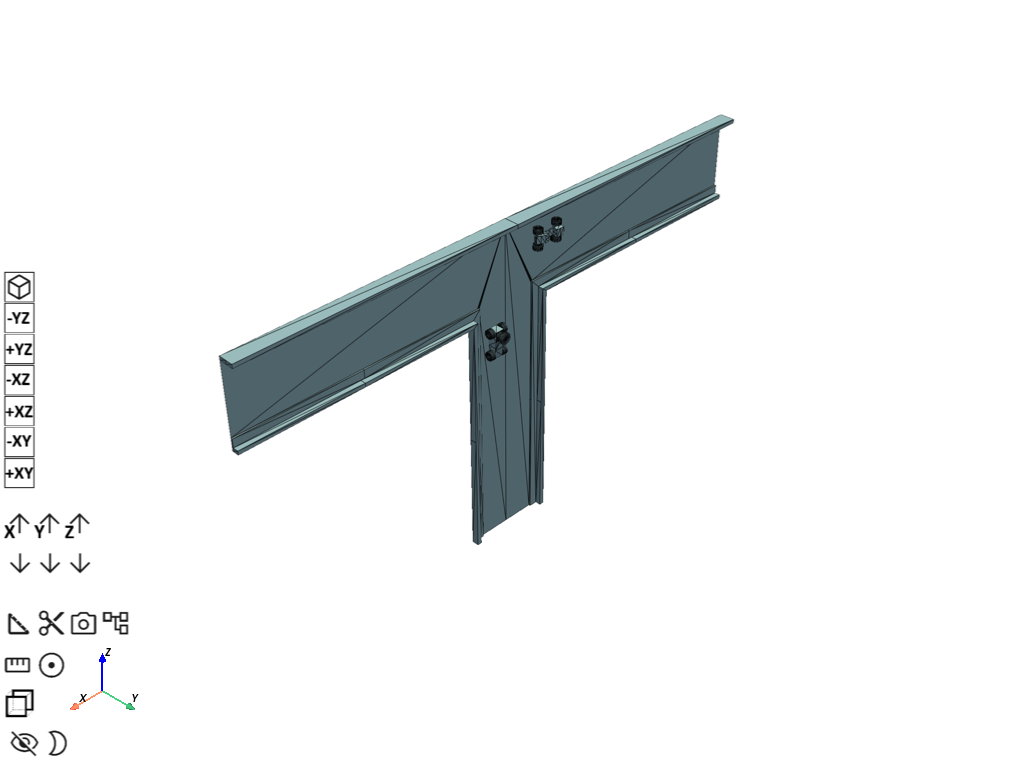

In [8]:
p.preview()

## Complete the project with sensor/source/simulation

We are adding a camera sensor to have output results, a luminaire to have a light source.

And, we gather the source and the sensor into a simulation (we will compute it just after).

### Create a sensor

In [9]:
ssr = p.create_sensor(name="Camera.1", feature_type=SensorCamera)
ssr.distortion_file_uri = str(
    assets_data_path / "CameraInputFiles" / "CameraDistortion_190deg.OPTDistortion"
)
ssr.set_mode_photometric().transmittance_file_uri = str(
    assets_data_path / "CameraInputFiles" / "CameraTransmittance.spectrum"
)
color_mode = ssr.set_mode_photometric().set_mode_color()
color_mode.red_spectrum_file_uri = str(
    assets_data_path / "CameraInputFiles" / "CameraSensitivityRed.spectrum"
)
color_mode.blue_spectrum_file_uri = str(
    assets_data_path / "CameraInputFiles" / "CameraSensitivityBlue.spectrum"
)
color_mode.green_spectrum_file_uri = str(
    assets_data_path / "CameraInputFiles" / "CameraSensitivityGreen.spectrum"
)

In [10]:
ssr.axis_system = [-2000, 1500, 11000, -1, 0, 0, 0, 1, 0, 0, 0, -1]
ssr.commit()

### Create a source

In this example, a luminaire source is created with an IES file.

More details on creating/editing source examples can be found in core examples.

In [11]:
src = p.create_source(name="Luminaire.1", feature_type=SourceLuminaire)
src.intensity_file_uri = assets_data_path / "IES_C_DETECTOR.ies"
src.spectrum.set_daylightfluorescent()
src.axis_system = [0, 10000, 50000, 1, 0, 0, 0, 1, 0, 0, 0, 1]

src.commit()

### Create a simulation

More details on creating/editing simulation examples can be found in core examples.

In [12]:
sim = p.create_simulation(name="Inverse.1", feature_type=SimulationInverse)
sim.sensor_paths = [ssr]
sim.source_paths = [src]
sim.commit()

## Run the simulation

Simulation can be run using CPU via compute_CPU method or using GPU via compute_GPU method.

In [13]:
run_sim = sim.compute_GPU if USE_GPU else sim.compute_CPU
run_sim()  # Run the simulation

[upload_response {
  info {
    uri: "15c5b979-2a85-4b81-a20f-f1338adfbb96"
    file_name: "Camera.1.Irradiance.xmp"
    file_size: 10643389
  }
}
, upload_response {
  info {
    uri: "801eccbf-6e1d-4510-945f-d007b689190f"
    file_name: "Camera.1.hdr"
    file_size: 518417
  }
}
, upload_response {
  info {
    uri: "5d042f6d-f342-40c6-a0d9-439d9c54a2a5"
    file_name: "Camera.1.xmp"
    file_size: 1809009
  }
}
, upload_response {
  info {
    uri: "bba23ddc-feed-4c6d-b4d1-64bd25fb7893"
    file_name: "Camera.1.png"
    file_size: 741109
  }
}
, upload_response {
  info {
    uri: "de6b9435-4b42-40a6-8965-ea66bc7cd98a"
    file_name: "Inverse.1.html"
    file_size: 997252
  }
}
]

## Check and review result

Open result

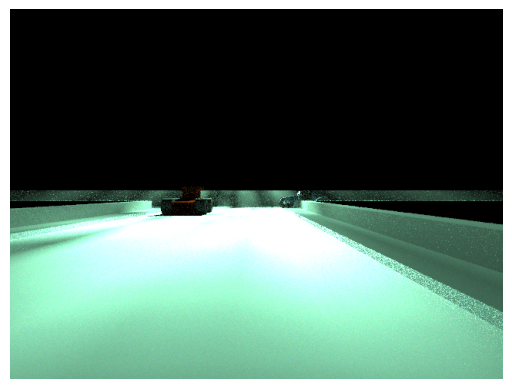

In [14]:
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=sim, result_name="Camera.1.png")

## Modify part

Move the part via changing the axis_system of a part.

axis_system is a list of 12 float values:
x, y, z,
x_vect_x, x_vect_y, x_vect_z,
y_vect_x, y_vect_y, y_vect_z,
z_vect_x, z_vect_y, z_vect_z.

In [15]:
blue_car_sub_part = p.find(name="BlueCar", feature_type=Part.SubPart)[0]
blue_car_sub_part.axis_system = [2000, 0.0, 20000, 0.0, 0.0, -1.0, -1.0, 0.0, 0.0, 0.0, 1.0, 0.0]
blue_car_sub_part.commit()

## Re-run simulation with the modified part position

In [16]:
run_sim()

[upload_response {
  info {
    uri: "f6b89ba8-b4de-4609-9946-7d24628a2c77"
    file_name: "Camera.1.Irradiance.xmp"
    file_size: 10383395
  }
}
, upload_response {
  info {
    uri: "51f69a58-bac3-4f0d-b54e-09fbfa5d6a2f"
    file_name: "Camera.1.hdr"
    file_size: 519919
  }
}
, upload_response {
  info {
    uri: "794efcc4-4f54-49da-a821-c739c3f1fc1f"
    file_name: "Camera.1.xmp"
    file_size: 1766385
  }
}
, upload_response {
  info {
    uri: "06883db4-3134-4b80-8da4-334becfd4266"
    file_name: "Camera.1.png"
    file_size: 728640
  }
}
, upload_response {
  info {
    uri: "533b34e5-9174-41ce-bafe-644b354c00b5"
    file_name: "Inverse.1.html"
    file_size: 981964
  }
}
]

Review result:

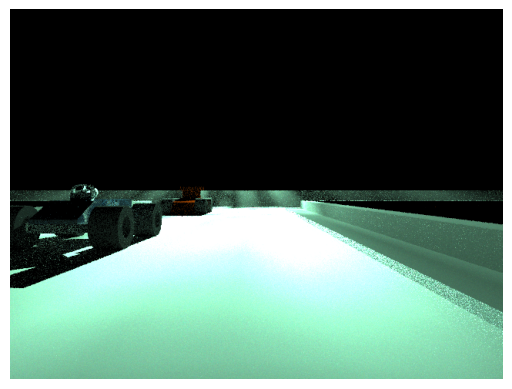

In [17]:
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    open_result_image(simulation_feature=sim, result_name="Camera.1.png")

## Modify camera property

Modify the camera, e.g. focal length to 10

In [18]:
cam1 = p.find(name="Camera.1", feature_type=SensorCamera)[0]
cam1.focal_length = 10
cam1.commit()

Re-run the simulation and review result

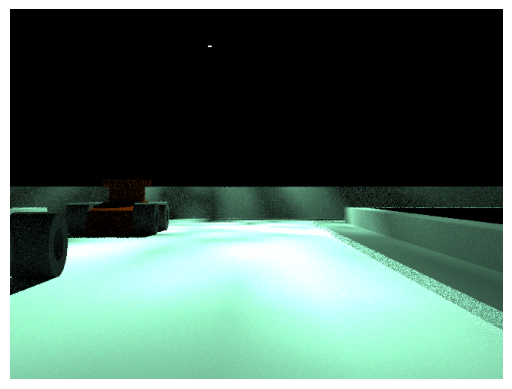

In [19]:
run_sim()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    open_result_image(simulation_feature=sim, result_name="Camera.1.png")

In [20]:
speos.close()

True